In [1]:
import os
import sys
from pathlib import Path
from pyprojroot import here

import copy
import time
import random
import subprocess

import numpy as np
import pandas as pd
from scipy.stats import norm
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT_DIR = here()
FORECASTING_DIR = ROOT_DIR / "4_forecasting"
DATA_DIR = ROOT_DIR / "1_data" / "processed"

sys.path.insert(0, str(FORECASTING_DIR)) # make forecasting module importable
os.path.join(FORECASTING_DIR, "forecasting.py")

'/home/fleet75/diss_bess/4_forecasting/forecasting.py'

In [3]:
# tested core — same directory
from forecasting import (
    QUANTILE_LEVELS, HIST_COLS, FEAT_COLS, EXO_COLS,
    TRAIN_START, VAL_START, TEST_START, TEST_END,
    build_features, reindex_and_impute, make_windows,
    fit_scalers, normalise_hist, normalise_y, denormalise_y,
    Baseline_Forecaster, pinball_loss,
)


In [48]:
# ---- reproducibility (record SEED in the checkpoint) ----
SEED = 20240801
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| seed:", SEED)


device: cpu | seed: 20260801


In [5]:
base_data = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"])
base_data.set_index("datetime", inplace=True)

base_data  = reindex_and_impute(base_data, HIST_COLS, freq="1h", warn_gap=6)
frame_full = build_features(base_data, feature_cols=FEAT_COLS)
print("frame_full:", frame_full.shape, "|", frame_full.index.min(), "->", frame_full.index.max())


[impute] 65 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 19 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
frame_full: (23520, 11) | 2017-11-03 00:00:00+00:00 -> 2020-07-09 23:00:00+00:00


In [6]:
# load in model checkpoint (weights + optimizer state + training metadata)
forecaster_checkpoint = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only = False, map_location="cpu")

In [7]:
forecaster_checkpoint.keys()

dict_keys(['state_dict', 'model_config', 'best_lr', 'scaler_stats', 'quantile_levels', 'split_dates', 'fixed_hparams', 'early_stopping', 'val_pinball', 'best_epoch', 'seed', 'git_sha', 'grid_results'])

In [8]:
model_config = forecaster_checkpoint["model_config"]
model = Baseline_Forecaster(**model_config) 

# 3. Load the trained weights into the model
model.load_state_dict(forecaster_checkpoint["state_dict"])

# 4. Set the model to evaluation mode before running inference
model.eval()

# 5. Extract ancillary data needed for inference or analysis
sc = forecaster_checkpoint["scaler_stats"]
QUANTILE_LEVELS = forecaster_checkpoint["quantile_levels"]
best_val_loss = forecaster_checkpoint["val_pinball"]
best_lr = forecaster_checkpoint["best_lr"]

In [9]:
#load data
h = pd.Timedelta(hours=1)

copula_windows = make_windows(
    frame_full, y_range=(TRAIN_START, VAL_START - h),
    gate_aligned_only=True, issue_hour=9,
    exo_cols=EXO_COLS, hist_cols=HIST_COLS, target_col="prosumption",
)

x_hist = copula_windows.x_hist
x_fut = copula_windows.x_fut

x_hist_n = normalise_hist(x_hist, sc)

y = copula_windows.y
y_n = normalise_y(y, sc)
deliv_start = copula_windows.ds
deliv_end = copula_windows.de

In [10]:
deliv_start, deliv_end, x_hist.shape, x_fut.shape, y.shape

(Timestamp('2018-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2018-12-31 23:00:00+0000', tz='UTC'),
 (365, 168, 4),
 (365, 24, 7),
 (365, 24))

In [11]:
len(x_hist)

365

In [46]:
predictions = np.array([])

def _t(a):
    return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

preds = []
for x in range(len(x_hist)):
    with torch.no_grad():
        # remember: unsqueeze adds a dimension to the tensor, so that the model can process it as a batch of size 1
        out = model(_t(x_hist_n[x]).unsqueeze(0), _t(x_fut[x]).unsqueeze(0))
    preds.append(out.squeeze(0).cpu().numpy())   # (24, 19)
predictions = np.stack(preds, axis=0)            # (N, 24, 19) — explicit, no reshape guesswork


print ("predictions.shape:", predictions.shape, "| y.shape:", y.shape)

predictions.shape: (365, 24, 19) | y.shape: (365, 24)


qp.shape: (8760, 19)


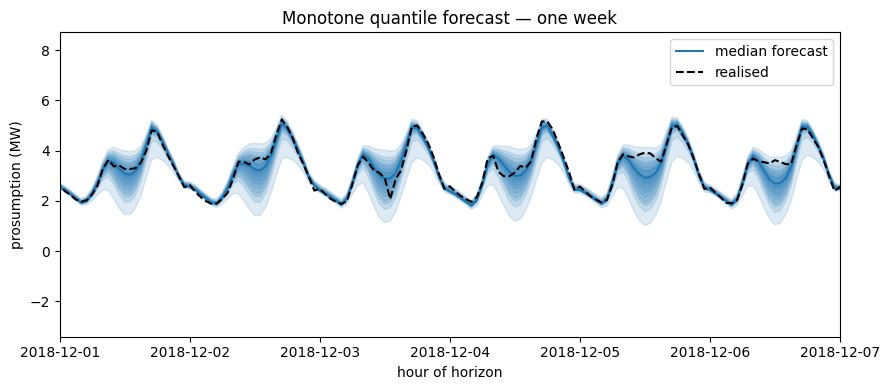

In [47]:
q_mw = denormalise_y(predictions, sc)
qp = q_mw.reshape(-1, 19)
print("qp.shape:", qp.shape)

time_idx = pd.date_range(start=deliv_start, end=deliv_end, freq="1h")

Yva = y.flatten()
mid = len(QUANTILE_LEVELS) // 2
plt.figure(figsize=(9, 4))
for k in range(mid):  # nested prediction bands
    plt.fill_between(time_idx, qp[:, k], qp[:, -1 - k], alpha=0.15, color="C0")
plt.plot(time_idx, qp[:, mid], color="C0", label="median forecast")
plt.plot(time_idx, Yva, "k--", label="realised")
plt.xlabel("hour of horizon")
plt.ylabel("prosumption (MW)")
plt.title("Monotone quantile forecast — one week")

plt.xlim(pd.Timestamp("2018-12-01 00:00:00+0000"), pd.Timestamp("2018-12-07 00:00:00+0000"))

#Timestamp('2018-01-01 00:00:00+0000', tz='UTC'),
#Timestamp('2018-12-31 23:00:00+0000', tz='UTC'),

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
(mid+1) * 0.05 

0.5

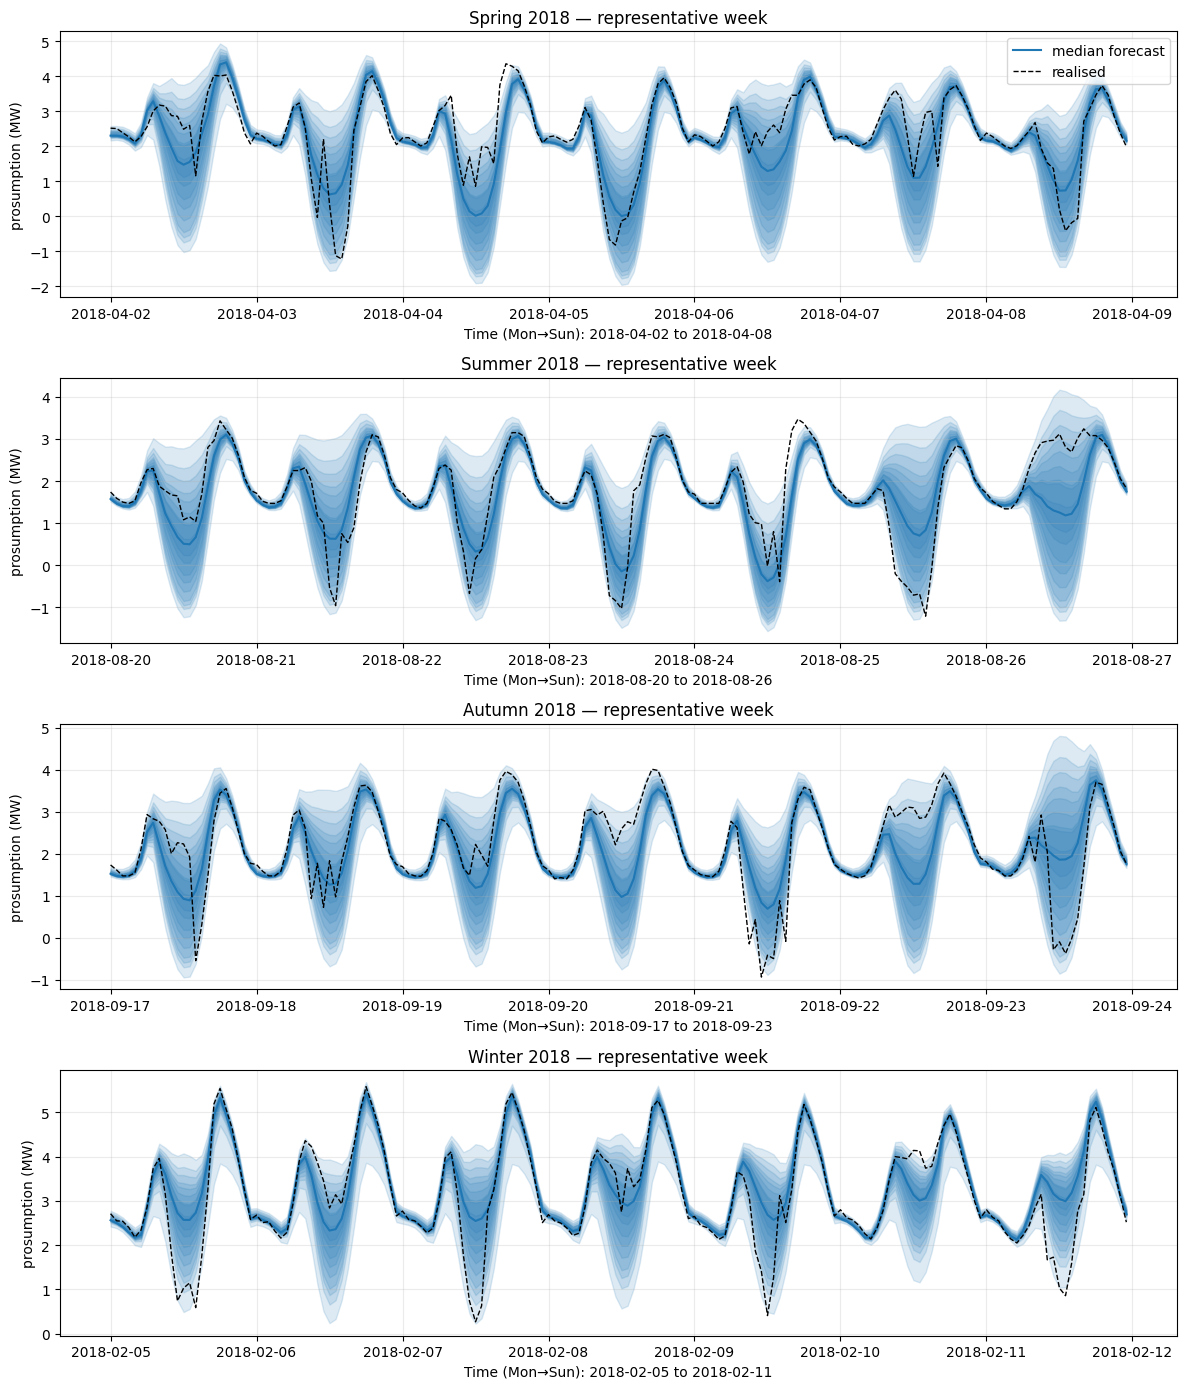

In [ ]:
window = 7 * 24  # 168 hours

season_map = {
    "Spring 2018": [3, 4, 5],
    "Summer 2018": [6, 7, 8],
    "Autumn 2018": [9, 10, 11],
    "Winter 2018": [12, 1, 2],
}

representative_weeks = []

for season_name, months in season_map.items():
    mask = time_idx.month.isin(months)
    t = time_idx[mask]
    y_season = Yva[mask]
    qp_season = qp[mask, :]
    
    seasonal_median = np.median(qp_season[:, mid])

    # Force week starts to be Mondays and full weeks to end on Sundays
    season_anchor = t[0].normalize() - pd.to_timedelta(t[0].weekday(), unit="D")
    week_starts = pd.date_range(
        start=season_anchor,
        end=t[-1].normalize(),
        freq="W-MON",
    )

    best_score = np.inf
    best_week_idx = None
    best_week_start = None

    for week_start in week_starts:
        week_end = week_start + pd.Timedelta(days=7)
        week_mask = (t >= week_start) & (t < week_end)
        week_idx = np.flatnonzero(week_mask)

        if len(week_idx) != window:
            continue

        week_qp = qp_season[week_idx, mid]
        score = np.mean(np.abs(week_qp - seasonal_median))

        if score < best_score:
            best_score = score
            best_week_idx = week_idx
            best_week_start = week_start

    if best_week_idx is None:
        raise ValueError(f"No full Monday→Sunday representative week found for {season_name}")

    t_week = t[best_week_idx]
    y_week = y_season[best_week_idx]
    qp_week = qp_season[best_week_idx, :]

    week_end = best_week_start + pd.Timedelta(days=6, hours=23)
    representative_weeks.append(
        (season_name, t_week, y_week, qp_week, best_week_start, week_end)
    )

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
fig.subplots_adjust(hspace=0.35)

for ax, (season_name, t_week, y_week, qp_week, week_start, week_end) in zip(axes, representative_weeks):
    for k in range(mid):
        ax.fill_between(
            t_week,
            qp_week[:, k],
            qp_week[:, -1 - k],
            alpha=0.15,
            color="C0",
        )

    ax.plot(t_week, qp_week[:, mid], color="C0", linewidth=1.5, label="median forecast")
    ax.plot(t_week, y_week, "k--", linewidth=1.0, label="realised")

    ax.set_title(f"{season_name} — representative week")
    ax.set_ylabel("prosumption (MW)")
    ax.grid(alpha=0.25)

    # X-axis label explicitly shows the Monday→Sunday week window
    ax.set_xlabel(
        f"Time (Mon→Sun): {week_start.strftime('%Y-%m-%d')} to {week_end.strftime('%Y-%m-%d')}"
    )

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## make dat copula babey

In [ ]:
from scipy.stats import norm

EPS = 1e-6

class MarginalDistCDF:
    """One lead time's predictive distribution from quantile forecasts, as a
    monotone CDF (F̂) / inverse-CDF (F̂⁻¹) by piecewise-linear interpolation.
    Used for PIT during estimation and for the non-differentiable eval path."""

    def __init__(
            self,
            levels,
            values,
            lower=None,
            upper=None
            ):
        levels = np.asarray(levels, float)

        # below not rlly necessary due to softmax + eps in forecaster but doubly ensures monotonicity.
        values = np.asarray(values, float)
        assert np.all(np.diff(values) > 0), "ERROR: marginal quantile values are not strictly monotonic!"

        ## Construct all points on the CDF from the forecaster's marginal distribution.
        
        ## Step 1: Ensure top and bottom of CDF are defined properly.
        # remember: probability is y-axis (levels), value is x-axis (values)

        # need to make sure we define a bottom value (x-axis) for every CDF.
        # if no lower bound defined before:
        # lower = bottom quantile + slope of bottom two quantiles * difference between 0 and lowest quantile prob
        if lower is None:
            slope = (values[1] - values[0]) / (levels[1] - levels[0])
            lower = values[0] + slope * ( 0 - levels[0])
        
        # for upper, same but reverse
        # upper = top quantile + slope of top two quantiles * difference between 1 and top quantile prob
        if upper is None:
            slope = (values[-1] - values[-2]) / (levels[-1] - levels[-2])
            upper = values[-1] + slope * (1.0 - levels[-1])

        l = np.concatenate(([0.0], levels, [1.0]))
        v = np.concatenate(([lower], values, [upper]))

        assert np.all(np.diff(l) > 0), "ERROR: appended 0.0 or 1.0 violates monotonicity of quantile LEVELS (check if levels already contain 0 or 1)"
        assert np.all(np.diff(v) > 0), "ERROR: extrapolated lower/upper bounds violated monotonicity of quantile VALUES"

        # define levels and values as instance attributes
        self._l = l
        self._v = v

    def cdf(self, x):
        """
        linearly interpollated CDF. Takes prosumption input, and returns
        corresponding CDF probability in [0,1] space.
        Does this by linearly interpollating CDF based on input discrete quantiles levels and values.
        """
        return np.interp(np.asarray(x, float), self._v, self._l)

    def inv_cdf(self, u):
        """
        Takes probability from [0,1] space, and returns exact prosumption relating to that CDF probability level
        Does this by linearly interpolating the cdf based on input discrete quantiles levels and values.
        """
    
        u = np.asarray(u, float)
    
        assert np.all((u >= 0.0) & (u <= 1.0)), (
        f"Probability input 'u' must be between 0.0 and 1.0 inclusive. "
        f"Got range [{u.min()}, {u.max()}].")

        # originally clipped values, change back if I do actually want to clip them, not generate error.
        #u = np.clip(np.asarray(u, float), 0.0, 1.0)

        return np.interp(u, self._l, self._v)


def build_probit_matrix(realisations, quantiles, levels=QUANTILE_LEVELS, eps = EPS):
    """
    Prob. integral transform + probit of the baseline forecaster's errors, for estimating copula covariance.

    realisations : (N_days, K) realised prosumption.
    quantiles    : (N_days, K, Q) the BASELINE forecaster's quantiles for each day.
    returns X    : (N_days, K) standard-normal transformed errors.
    """
    realisations = np.asarray(realisations, float)
    quantiles = np.asarray(quantiles, float)
    N, K = realisations.shape
    X = np.empty((N, K))
    for d in range(N):
        for k in range(K):
            # for each time-step:
            #create class that stores
            marginal_dist = MarginalDistCDF(levels, quantiles[d, k])

            # Ensure u stays at least 1e-6 away from 0 and 1
            # so norm.ppf (normal dist inv-CDF) yields finite values instead of +/-inf
            u = np.clip(marginal_dist.cdf(realisations[d, k]), eps, 1 - eps)
            X[d, k] = norm.ppf(u) # builds normalised error matrix, one value at a time.
    return X

In [41]:
quantiles = q_mw.reshape(-1,24,19)
X = build_probit_matrix(y,quantiles)
year_corr_matrix = np.corrcoef(np.asarray(X, dtype=float), rowvar=False)   # (K, K)

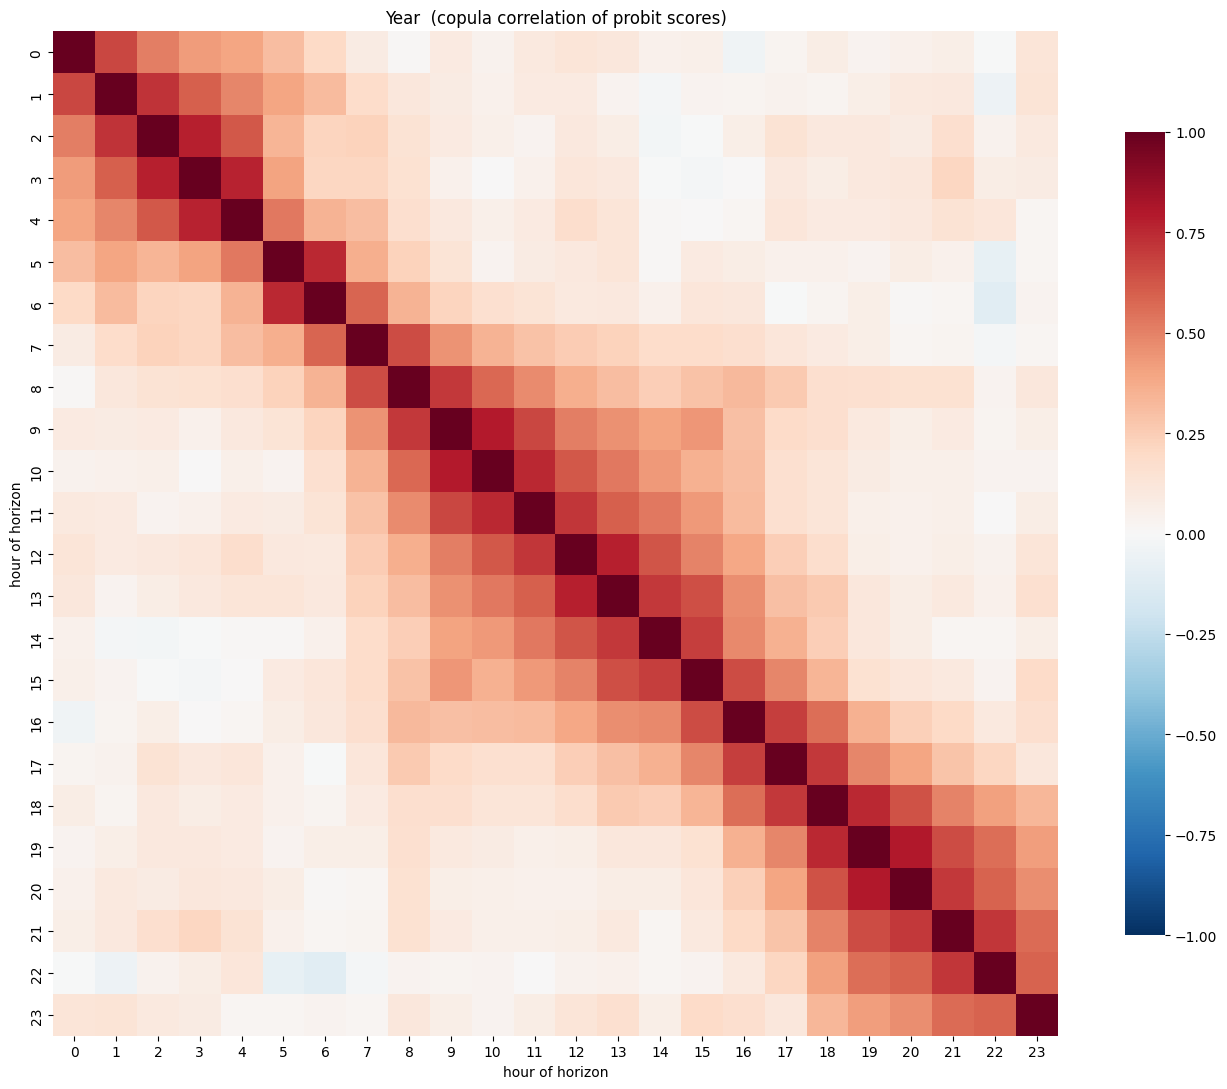

In [42]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(year_corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r",
            square=True, cbar_kws={"shrink": 0.8},
            xticklabels=range(24), yticklabels=range(24))
ax.set_title(f"Year  (copula correlation of probit scores)")
ax.set_xlabel("hour of horizon")
ax.set_ylabel("hour of horizon")
plt.tight_layout()
plt.show()

Winter: 90 days
Spring: 92 days
Summer: 92 days
Autumn: 91 days


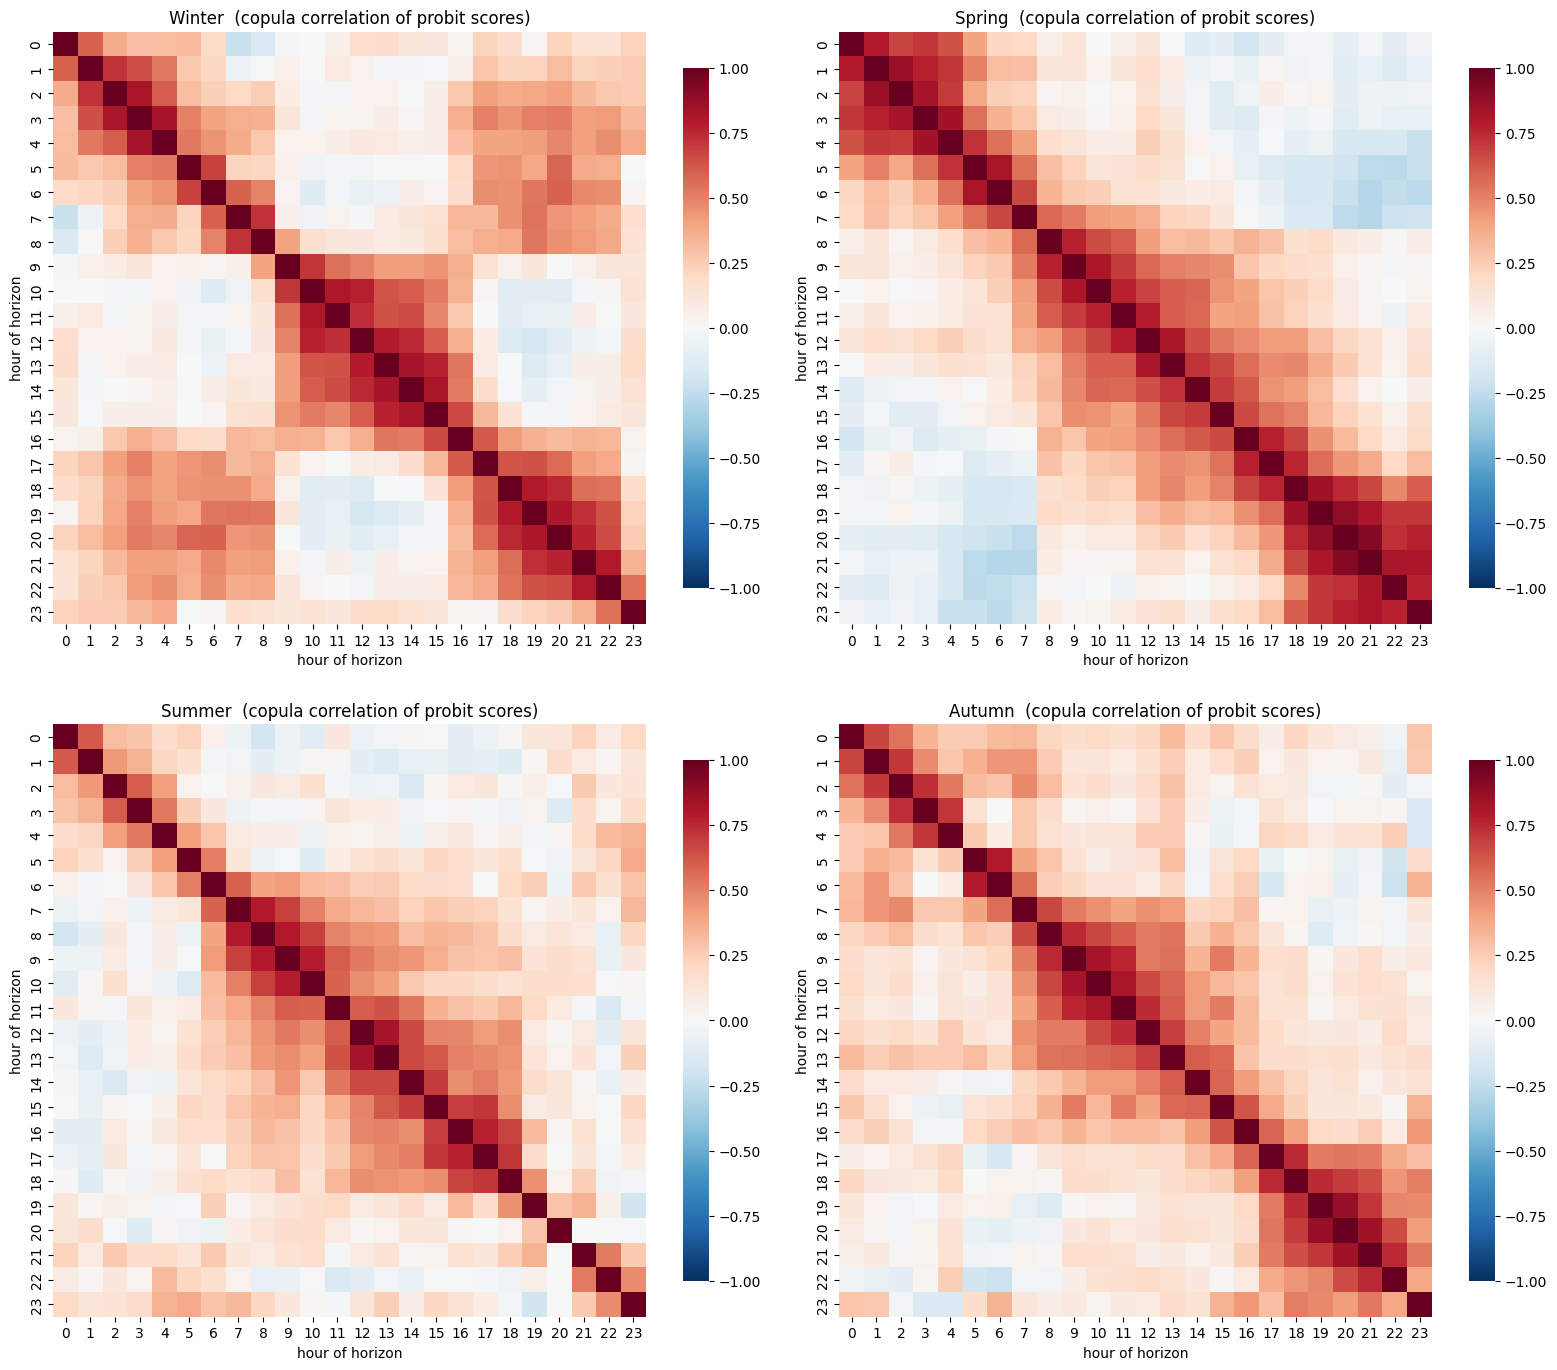

In [43]:
def seasonal_correlation_matrices(X, dates=None, year=2018):
    """
    X: (N_days, 24) probit/PIT scores — daily samples, hourly variables.
    dates: optional DatetimeIndex of length N_days giving each row's date.
           If None, rows are assumed to be consecutive calendar days from Jan 1.
    Returns dict {season_name: (24,24) correlation matrix}.
    """
    X = np.asarray(X, dtype=float)
    n = X.shape[0]

    if dates is None:
        # ASSUMPTION: row i = Jan 1 + i days. Only valid if no days were dropped.
        dates = pd.date_range(f"{year}-01-01", periods=n, freq="D")
    else:
        dates = pd.DatetimeIndex(dates)

    # meteorological seasons by month
    month_to_season = {12: "Winter", 1: "Winter", 2: "Winter",
                       3: "Spring", 4: "Spring", 5: "Spring",
                       6: "Summer", 7: "Summer", 8: "Summer",
                       9: "Autumn", 10: "Autumn", 11: "Autumn"}
    season = dates.month.map(month_to_season)

    order = ["Winter", "Spring", "Summer", "Autumn"]
    mats = {}
    for s in order:
        rows = X[season == s]
        # np.corrcoef with rowvar=False -> (24,24), variables = columns (hours)
        mats[s] = np.corrcoef(rows, rowvar=False)
        print(f"{s}: {rows.shape[0]} days")
    return mats


def plot_seasonal_correlations(mats):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    for ax, (season, C) in zip(axes.flat, mats.items()):
        sns.heatmap(C, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r",
                    square=True, cbar_kws={"shrink": 0.8},
                    xticklabels=range(24), yticklabels=range(24))
        ax.set_title(f"{season}  (copula correlation of probit scores)")
        ax.set_xlabel("hour of horizon")
        ax.set_ylabel("hour of horizon")
    plt.tight_layout()
    plt.show()


mats = seasonal_correlation_matrices(X, year=2018)   # pass dates=... if you have them
plot_seasonal_correlations(mats)

In [20]:
year_corr_matrix.shape

(24, 24)

In [21]:
import numpy as np
from scipy.stats import qmc, norm



def build_Z_corr(corr_matrix, K = 24,seed = SEED,n = 256, eps = EPS):
    """
    Uses Sobol sequences to build an evenly distributed, representative Z_corr that can be frozen.
    """
    
    # 1. Initiate Sobol sequence sampler
    sampler = qmc.Sobol(d=K, scramble=True, seed=seed)

    # 2. Draw evenly spread points in [0, 1]^K
    u_samples = sampler.random(n=n)  # Shape: (n, K)

    # 3. Prevent exact 0 and 1 boundaries for norm.ppf safety
    u_samples = np.clip(u_samples, eps, 1 - eps)

    # 4. Transform uniform QMC samples to Standard Normal N(0, I) using inverse standard normal CDF
    Z = norm.ppf(u_samples)  # Shape: (n, K)

    # 5. Apply Cholesky factor of the Target Covariance Matrix
    L_corr = np.linalg.cholesky(corr_matrix)
    Z_corr = Z @ L_corr.T  # Shape: (n, K)
    return Z_corr

Z_corr = build_Z_corr(year_corr_matrix, K=24, seed=SEED, n=256, eps=1e-6)

In [22]:

"""
Two parts, by design:

  A. One-time estimation (NumPy, run before DFL)
       build_probit_matrix(...)         PIT + probit of historical errors
       estimate_frozen_correlation(...) pooled + shrinkage -> frozen Σ
       PredictiveMarginal, generate_scenarios_numpy(...)  (non-diff; baseline/eval)

  B. Per-step generation (PyTorch, inside the DFL loop)
       FrozenCopulaSampler              Σ + draws frozen; differentiable in the
                                        forecaster's quantile outputs.


"""

"\nTwo parts, by design:\n\n  A. One-time estimation (NumPy, run before DFL)\n       build_probit_matrix(...)         PIT + probit of historical errors\n       estimate_frozen_correlation(...) pooled + shrinkage -> frozen Σ\n       PredictiveMarginal, generate_scenarios_numpy(...)  (non-diff; baseline/eval)\n\n  B. Per-step generation (PyTorch, inside the DFL loop)\n       FrozenCopulaSampler              Σ + draws frozen; differentiable in the\n                                        forecaster's quantile outputs.\n\n\n"

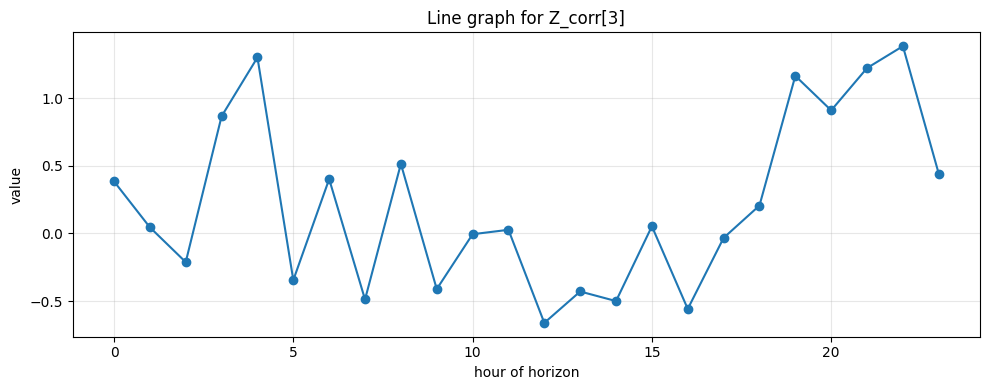

In [23]:
n = 3
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(Z_corr[n])), Z_corr[n], marker="o", linewidth=1.5)
plt.xlabel("hour of horizon")
plt.ylabel("value")
plt.title(f"Line graph for Z_corr[{str(n)}]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import torch
import torch.nn as nn

def _precompute_plan(Z_corr, levels, eps = EPS):
    """
    This function pre-maps where the Z_corr variables fall within the array of probability levels of the CDF quantiles.
    As Z_corr is frozen, this only has to be computed once. Doing it now speeds up computation later on using pytorch,
    as pytorch doesn't have to search which quantiles a given point sits between each time it checks.
    """

    levels = np.asarray(levels, float)
    # Add 0.0 and 1.0 probability values to the grid. This allows pytorch to extrapolate tail values later.
    l_aug = np.concatenate(([0.0], levels, [1.0]))                    # (num_quantiles + 2,)

    assert np.all(np.diff(l_aug) > 0), "Probability levels must be strictly monotonic"

    # transform Z_corr to uniform space by passing it through normal CDF, 
    # so that we can find each Z_corr value in (S,K)'s respective index
    # within the respective marginal distribution's CDF.
    u = np.clip(norm.cdf(Z_corr), eps, 1.0 - eps)                     # clip by EPS for numerical stability around boundary values
    # u represents all scenario timesteps values in uniform space.
    num_pts = l_aug.shape[0]                                          # num_pts = num_quantiles + 2

    # finds array location for each uniformly transformed scenario timestep in marginal dist's quantiles in uniform space.
    idx = np.clip(np.searchsorted(l_aug, u, side="right") - 1, 0, num_pts - 2)  # finds index of (S,K) in [0,num_quantiles]
    
    # find how far between two surrounding quantile values each scenario timestep is. 
    # w is the fraction showing how much distance u has between the quantiles below and above it
    # in uniform probability space.
    # (distance from bottom) / (distance between top and bottom)
    w = (u - l_aug[idx]) / (l_aug[idx + 1] - l_aug[idx])              # (S,K)

    ## Also need median quantiles location in index for converting scenarios to errors for the optimiser.
    # if we don't know for certain that we have a quantile at 50% probability on CDF,
    # we can find the closest match by subtracting 0.5 from all quantile values,
    # taking the absolute value (so that each value now represents the distance of the 
    # quantil from the middle) and finding the smallest value. 
    med_idx = int(np.argmin(np.abs(l_aug - 0.5)))
    return idx.astype(np.int64), w.astype(np.float32), med_idx

class FrozenCopulaSampler(nn.Module):
    """
    Differentiable Gaussian-copula sampler with FROZEN Σ and FROZEN draws.

    Precomputes ONCE, from the frozen draws and the quantile LEVELS only:
        correlated normal draws -> uniforms -> (bracket-index, weight) plan
    against the augmented level grid [0, levels..., 1].
    The plan is independent of the forecast VALUES, so it stays valid for
    every DFL step. During training, `prosumption` / `errors` interpolate the
    CURRENT forecaster quantiles through that frozen plan — differentiable in
    the quantiles (marginals), constant in Sigma/draws.

    Args
    ----
    Z_corr : (S, K) frozen pre-drawn correlated standard-normal samples.
    levels : (num_quantiles,)   quantile levels the forecaster emits (must NOT include 0 or 1).
    """

    def __init__(self, Z_corr, levels=QUANTILE_LEVELS):
        super().__init__()
        levels = np.asarray(levels, dtype=float)

        self.num_quantiles = len(levels)
        self.S, self.K = Z_corr.shape

        # calculations all done with tail-extrapolated CDF.
        idx, w, med_idx = _precompute_plan(Z_corr, levels)   # pre-computes levels to speed up scenario gen
        self.med_idx = med_idx

        # idx indexes the augmented (num_quantiles+2) value grid, so it must live in [0, num_quantiles]
        assert idx.min() >= 0 and idx.max() <= self.num_quantiles, (
            f"idx range [{idx.min()},{idx.max()}] inconsistent with augmented grid "
            f"(expected [0,{self.num_quantiles}]); is _precompute_plan using the [0,levels,1] grid?"
        )

        # frozen buffers (move with .to(device), never trained)
        self.register_buffer("idx", torch.as_tensor(idx, dtype=torch.long))     # (S, K)
        self.register_buffer("w", torch.as_tensor(w, dtype=torch.float32))      # (S, K)
        self.register_buffer("levels_t", torch.as_tensor(levels, dtype=torch.float32))  # (num_quantiles,)

    # ------------------------------------------------------------------ #
    def _augmented_values(self, quantiles):
        """
        quantiles : (K, num_quantiles) monotone forecast quantiles (requires grad).
        returns   : (K, num_quantiles+2) grid [lower, quantiles..., upper] with slope-
                    extrapolated tail endpoints, differentiable in quantiles.
        """
        if quantiles.dim() != 2:
            raise ValueError("expects (K, num_quantiles) for one day; loop or batch externally")
        K, num_quantiles = quantiles.shape
        if num_quantiles != self.num_quantiles:
            raise ValueError(f"quantiles has num_quantiles={num_quantiles}, sampler built for num_quantiles={self.num_quantiles}")

        ## ensure that all calculations are done on same device and at same precision
        lev_t = self.levels_t.to(quantiles)                                      # (num_quantiles,)
    
        ## uses same logic as in piecewise linear CDF class
        # now, instead of finding the slope between each quantile per individual timestep, 
        # we want to do it for a matrix representing an entire window of K steps.
        # lower = q0 + (q1-q0)/(l1-l0) * (0 - l0)
        slope_lo = (quantiles[:, 1] - quantiles[:, 0]) / (lev_t[1] - lev_t[0])      # (K,)
        lower = quantiles[:, 0] + slope_lo * (0.0 - lev_t[0])                    # (K,)
        # upper = q_{-1} + (q_{-1}-q_{-2})/(l_{-1}-l_{-2}) * (1 - l_{-1})
        slope_hi = (quantiles[:, -1] - quantiles[:, -2]) / (lev_t[-1] - lev_t[-2])  # (K,)
        upper = quantiles[:, -1] + slope_hi * (1.0 - lev_t[-1])                  # (K,)

        return torch.cat([lower.unsqueeze(1), quantiles, upper.unsqueeze(1)], dim=1)  # (K, num_quantiles+2)


    def _interpolate(self, v_aug):
        """Gather the frozen bracket plan through the augmented values -> (S, K)."""
        K = v_aug.shape[0]
        vexp = v_aug.unsqueeze(0).expand(self.S, K, self.num_quantiles + 2)             
        # unsqueeze takes the matrix of augment values for each quantile, 
        # and adds new dimension at front of tensor to represent scenarios.
        # expand expands this dimension so that the tensor is duplicated
        # num_scenario times across the scenario dimension.
        # now, vexp represents the quantile values for each timestep, duplicated 
        # for every scenario.
        # It is now ready to interpolate the values for each timestep for each scenario
        # based on the precalculated idx values, weights and augment values (quantile values + 0 and 1 prob values)
        # final dimensions of vexp are (S, K, num_quantiles+2)

        # for each scenario's timestep, we want to find the values of the quantiles above and below
        # the scenario's value using the precomputed idx values.
        # Since we have precomputed the distance of each value between the quantiles above and below
        # it in uniform probability space already, we know that the realised value of that scenario's
        # timestep is the value of the below quantile, plus the distance of the point between the below and above
        # quantiles in probability space, multiplied by the distance between these quantiles in value space.  
        
        v_lo = torch.gather(vexp, 2, self.idx.unsqueeze(-1)).squeeze(-1)      # (S, K)
        v_hi = torch.gather(vexp, 2, (self.idx + 1).unsqueeze(-1)).squeeze(-1)  # (S, K)
        # To find the below and above quantile values:
        # for each value:
        # - unsqueeze the precomputed idx values so they have same number of dimensions as vexp
        # - use torch.gather to look along the third dimension of vexp (the quantile value dimension)
        # - torch.gather outputs a tensor that matches the shape of the index tensor provided.
        #   Therefore, the output of gather is (S, K, 1), as it only returns the index of a SINGLE quantile.
        # - Since we don't want that final dimension and there is only one of it, we can use 
        #   squeeze to remove it.
        # - this results in an (S,K) shaped tensor for each of v_lo and v_hi,
        #   which represents the above and below quantiles for each timestep of each scenario.
        #
        # - From here, all we have to do is return the final tensor of the interpolated final value of each
        #   scenario's timesteps, based on the precomputed values!
        return v_lo + self.w * (v_hi - v_lo)

    # ------------------------------------------------------------------ #
    def prosumption(self, quantiles):
        """
        quantiles : (K, num_quantiles) monotone quantile forecasts (torch, requires grad).
        returns   : (S, K) prosumption scenarios p^l, differentiable in quantiles.

        Tails are slope-extrapolated to prob 0/1 (no clamping), matching
        MarginalDistCDF, so scenarios can exceed the outer quantiles.
        """
        v_aug = self._augmented_values(quantiles)
        return self._interpolate(v_aug)

    def errors(self, quantiles, y_true):
        """
        Convenience: scenario forecast errors (scenario - realised).
        quantiles : (K, num_quantiles) ; y_true : (K,) realised prosumption.
        returns   : (S, K) errors, differentiable in quantiles.
        """
        p = self.prosumption(quantiles)                                      # (S, K)
        return p - y_true.to(p).unsqueeze(0)                                 # broadcast (1,K)

In [25]:
idx = 180

quantiles_t = torch.as_tensor(quantiles[idx, :, :], dtype=torch.float32, device=DEVICE)
QUANTILE_LEVELS_t = torch.as_tensor(QUANTILE_LEVELS, dtype=torch.float32, device=DEVICE)

sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS)
scenarios = sampler.prosumption(quantiles_t)
scenario_array = scenarios.detach().cpu().numpy()

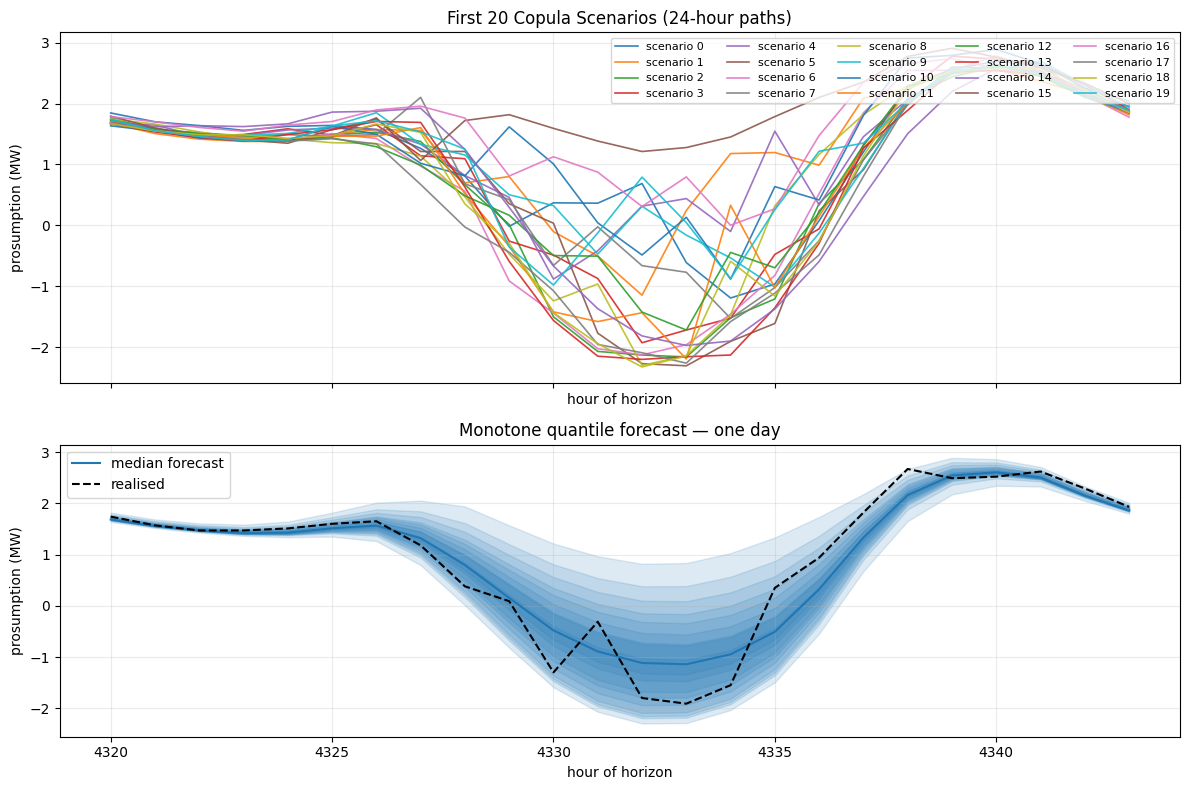

In [26]:
idx = 180

quantiles_t = torch.as_tensor(quantiles[idx, :, :], dtype=torch.float32, device=DEVICE)
QUANTILE_LEVELS_t = torch.as_tensor(QUANTILE_LEVELS, dtype=torch.float32, device=DEVICE)

sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS)
scenarios = sampler.prosumption(quantiles_t)
scenario_array = scenarios.detach().cpu().numpy()

day_idx = idx
hours_per_day = 24
start_idx = day_idx * hours_per_day
end_idx = start_idx + hours_per_day
time_axis = np.arange(start_idx, end_idx)

qp_day = qp[start_idx:end_idx, :]
Yva_day = Yva[start_idx:end_idx]
               
fig, (ax_scen, ax_day) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 1.0]}
)

# Top subplot: scenario paths
for i in range(min(20, scenario_array.shape[0])):
    ax_scen.plot(time_axis, scenario_array[i], linewidth=1.2, alpha=0.9)

ax_scen.set_xlabel("hour of horizon")
ax_scen.set_ylabel("prosumption (MW)")
ax_scen.set_title("First 20 Copula Scenarios (24-hour paths)")
ax_scen.grid(alpha=0.25)
ax_scen.legend(
    [f"scenario {i}" for i in range(min(20, scenario_array.shape[0]))],
    loc="upper right", ncol=5, fontsize=8
)

# Bottom subplot: quantile forecast + realised
for k in range(mid):
    ax_day.fill_between(time_axis, qp_day[:, k], qp_day[:, -1 - k], alpha=0.15, color="C0")

ax_day.plot(time_axis, qp_day[:, mid], color="C0", label="median forecast")
ax_day.plot(time_axis, Yva_day, "k--", label="realised")
ax_day.set_xlabel("hour of horizon")
ax_day.set_ylabel("prosumption (MW)")
ax_day.set_title("Monotone quantile forecast — one day")
ax_day.legend()
ax_day.grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [50]:
len(x_hist), deliv_start deliv_end

(365, Timestamp('2018-01-01 00:00:00+0000', tz='UTC'))

In [51]:
delta = deliv_end - deliv_start
print("timedelta:", delta)
print("days:", delta.days + 1)

timedelta: 364 days 23:00:00
days: 364


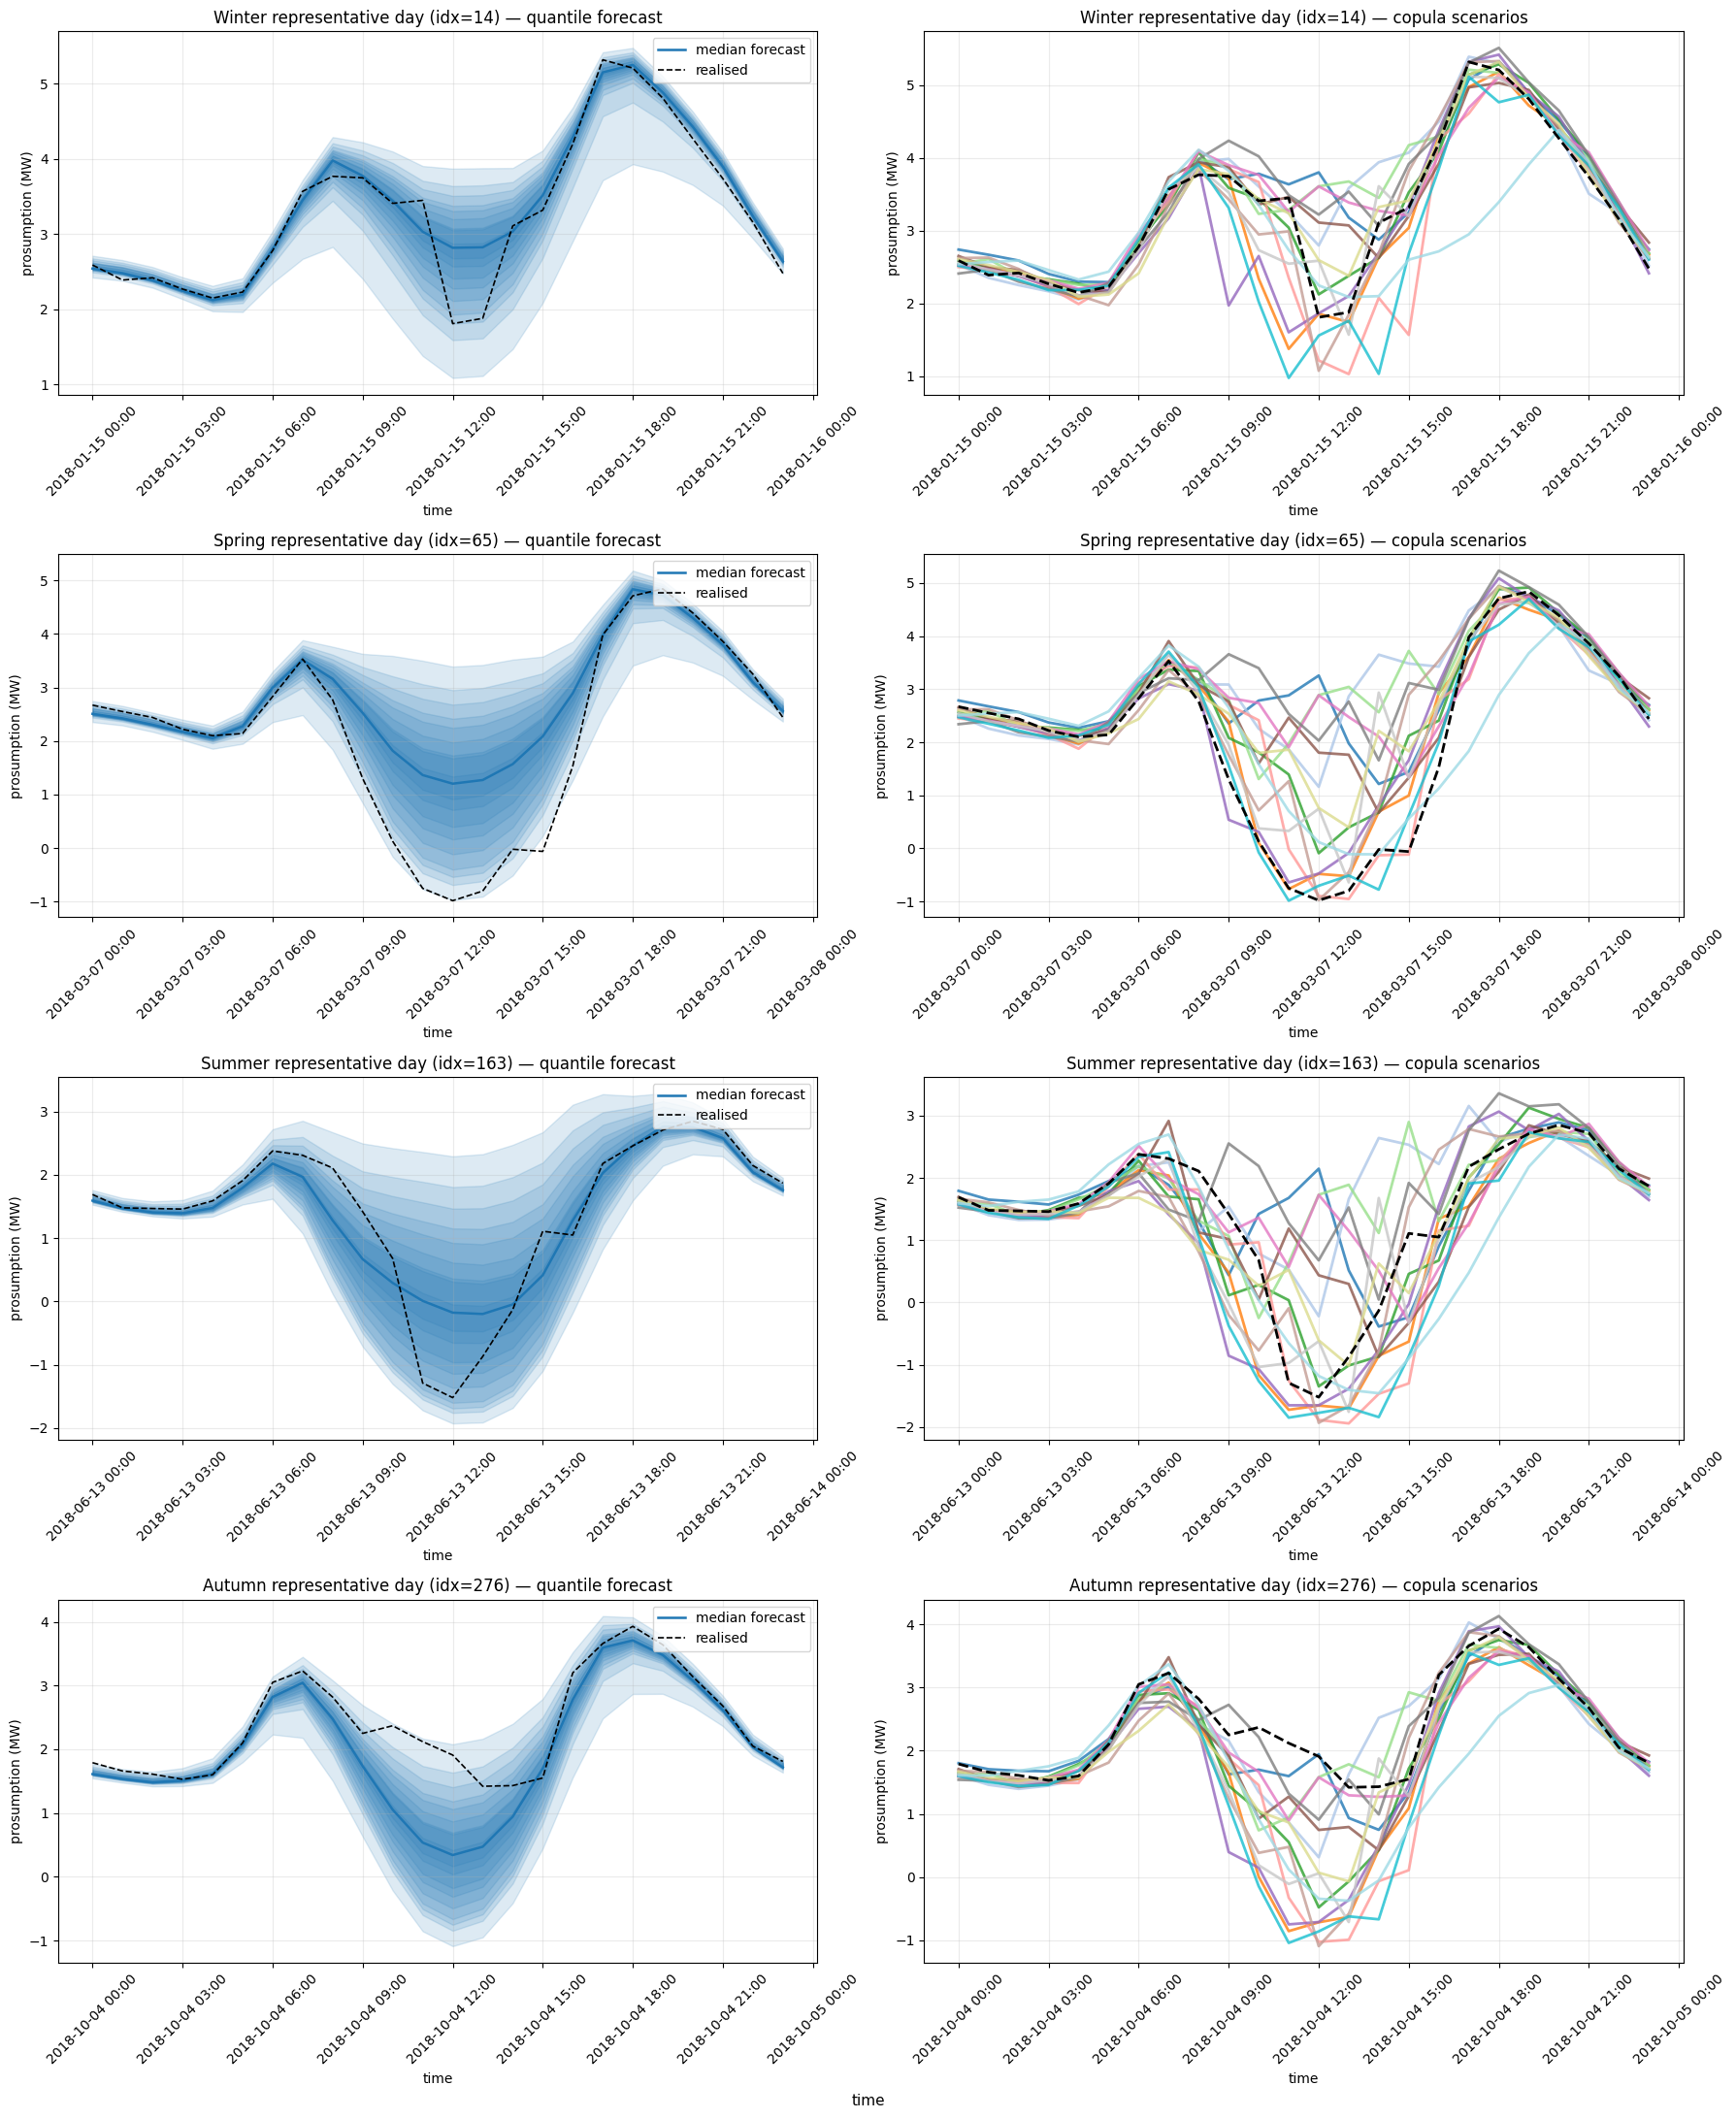

In [53]:
import matplotlib.dates as mdates

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_map = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11],
}

# Delimit the study period from the actual delivery window
data_start_day = pd.Timestamp(deliv_start).normalize()
data_end_day = pd.Timestamp(deliv_end).normalize()

days = pd.date_range(start=data_start_day, end=data_end_day, freq="D")
assert len(days) == y.shape[0], (
    f"Expected {y.shape[0]} daily rows from {data_start_day} to {data_end_day}, "
    f"got {len(days)} dates instead."
)

# Build representative day index per season using the actual date range
season_idx = {}
for season, months in season_map.items():
    mask = days.month.isin(months)
    day_candidates = np.flatnonzero(mask)
    daily_totals = y[day_candidates].sum(axis=1)
    med_total = np.median(daily_totals)
    best_day = day_candidates[np.argmin(np.abs(daily_totals - med_total))]
    season_idx[season] = int(best_day)

# Plot setup: 4 seasons × 2 graphs
fig, axes = plt.subplots(4, 2, figsize=(18, 22), sharex=False)
fig.subplots_adjust(hspace=0.45, wspace=0.22)

for row, season in enumerate(season_order):
    idx = season_idx[season]
    day_slice = slice(idx * 24, (idx + 1) * 24)

    time_axis = time_idx[day_slice]
    qp_day = qp[day_slice, :]
    y_day = y[idx]
    q_day = quantiles[idx, :, :]  # day-level forecast quantiles

    # Left subplot: forecast bands + realised day
    ax_fc = axes[row, 0]
    for k in range(mid):
        ax_fc.fill_between(
            time_axis,
            qp_day[:, k],
            qp_day[:, -1 - k],
            alpha=0.15,
            color="C0",
        )
    ax_fc.plot(time_axis, qp_day[:, mid], color="C0", linewidth=1.8, label="median forecast")
    ax_fc.plot(time_axis, y_day, "k--", linewidth=1.2, label="realised")
    ax_fc.set_title(f"{season} representative day (idx={idx}) — quantile forecast")
    ax_fc.set_ylabel("prosumption (MW)")
    ax_fc.grid(alpha=0.25)
    ax_fc.legend(loc="upper right")
    ax_fc.set_xlabel("time")
    ax_fc.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    ax_fc.tick_params(axis="x", rotation=45)

    # Right subplot: copula scenarios for the same representative day
    ax_sc = axes[row, 1]
    quantiles_t = torch.as_tensor(q_day, dtype=torch.float32, device=DEVICE)
    sampler = FrozenCopulaSampler(Z_corr, QUANTILE_LEVELS)
    scenarios = sampler.prosumption(quantiles_t).detach().cpu().numpy()

    n_plot = min(15, scenarios.shape[0])
    colors = plt.cm.tab20(np.linspace(0, 1, n_plot))

    for i in range(n_plot):
        ax_sc.plot(
            time_axis,
            scenarios[i],
            linewidth=2,
            alpha=0.8,
            color=colors[i],
        )

    ax_sc.plot(time_axis, y_day, "k--", linewidth=2, label="realised")
    ax_sc.set_title(f"{season} representative day (idx={idx}) — copula scenarios")
    ax_sc.set_ylabel("prosumption (MW)")
    ax_sc.grid(alpha=0.25)
    ax_sc.set_xlabel("time")
    ax_sc.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    ax_sc.tick_params(axis="x", rotation=45)

# A shared overall x-axis label for clarity
fig.supxlabel("time", fontsize=11)

plt.tight_layout()
plt.show()

In [28]:
def scenario_calibration_check(
    realised, scenarios, dates=None, year=2018,
    scenario_axis=1, midday_hours=range(9, 17),
    n_display_bins=20, seed=SEED,
):
    """
    Multivariate / ensemble calibration of copula scenarios.

    realised   : (N_days, K)          realised trajectories (K=24)
    scenarios  : (N_days, S, K)        S scenarios per day  (set scenario_axis if different)
    dates      : optional DatetimeIndex length N_days; else assumes consecutive days from Jan 1
    midday_hours: hours treated as the solar window for the summary

    Produces:
      - mean-PIT heatmap  (season x hour): 0.5 = well-centred;
            < 0.5 => ensemble sits too HIGH (realised low in ensemble);
            > 0.5 => ensemble sits too LOW  (realised high in ensemble)
      - per-season multivariate (average-rank) histograms:
            flat = calibrated; U = under-dispersed; dome = over-dispersed; slope = biased
      - printed midday summary per season
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(realised, dtype=float)                    # (N, K)
    S_arr = np.asarray(scenarios, dtype=float)
    if scenario_axis != 1:
        S_arr = np.moveaxis(S_arr, scenario_axis, 1)         # -> (N, S, K)
    N, S, K = S_arr.shape
    assert y.shape == (N, K), f"realised {y.shape} vs scenarios {(N, S, K)}"

    # ---- season labels ----
    if dates is None:
        dates = pd.date_range(f"{year}-01-01", periods=N, freq="D")
    dates = pd.DatetimeIndex(dates)
    m2s = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
           6:"Summer",7:"Summer",8:"Summer",9:"Autumn",10:"Autumn",11:"Autumn"}
    season = dates.month.map(m2s).to_numpy()
    order = ["Winter", "Spring", "Summer", "Autumn"]

    # ---- per-hour randomized rank of realised within the ensemble ----
    # rank in {0..S}; PIT = rank / S  (mean ~0.5 if centred)
    ranks_hour = np.empty((N, K), dtype=int)
    for h in range(K):
        col = S_arr[:, :, h]                                 # (N, S)
        below = (col <  y[:, [h]]).sum(axis=1)               # (N,)
        equal = (col == y[:, [h]]).sum(axis=1)               # (N,) ~0 for continuous
        ranks_hour[:, h] = below + rng.integers(0, equal + 1)
    pit_hour = ranks_hour / S                                # (N, K) in [0,1]

    # ---- multivariate average-rank of the whole 24h trajectory ----
    # robust in high-d (avoids the componentwise pre-rank degeneracy at K=24)
    mv_rank = np.empty(N, dtype=int)
    for d in range(N):
        pool = np.vstack([y[d][None, :], S_arr[d]])          # (S+1, K), row 0 = realised
        # ordinal rank within each column (ties negligible for continuous scenarios)
        uni = np.argsort(np.argsort(pool, axis=0, kind="mergesort"),
                         axis=0, kind="mergesort")           # (S+1, K), 0..S
        avg = uni.mean(axis=1)                               # (S+1,)
        obs = avg[0]
        n_less = int((avg < obs).sum())
        n_eq   = int((avg == obs).sum())
        mv_rank[d] = n_less + rng.integers(1, n_eq + 1)      # 1..S+1

    # ================= plots =================
    # (1) mean-PIT heatmap: season x hour
    heat = np.vstack([pit_hour[season == s].mean(axis=0) for s in order])   # (4, K)
    fig1, ax = plt.subplots(figsize=(13, 4))
    im = ax.imshow(heat, aspect="auto", cmap="RdBu_r", vmin=0.3, vmax=0.7)
    ax.set_yticks(range(4)); ax.set_yticklabels(order)
    ax.set_xticks(range(K)); ax.set_xticklabels(range(K))
    ax.set_xlabel("hour of horizon"); ax.set_title(
        "Mean ensemble-PIT of realised  (0.5 = centred;  <0.5 ensemble too high;  >0.5 ensemble too low)")
    for i in range(4):
        for h in range(K):
            ax.text(h, i, f"{heat[i,h]:.2f}", ha="center", va="center", fontsize=6)
    fig1.colorbar(im, shrink=0.8); plt.tight_layout()

    # (2) per-season multivariate rank histograms
    fig2, axes = plt.subplots(2, 2, figsize=(13, 8))
    bins = np.linspace(0.5, S + 1.5, min(n_display_bins, S + 1) + 1)
    for axh, s in zip(axes.flat, order):
        r = mv_rank[season == s]
        axh.hist(r, bins=bins, density=True, color="C0", edgecolor="white")
        axh.axhline(1.0 / (S + 1), color="k", ls="--", lw=1, label="uniform (calibrated)")
        axh.set_title(f"{s}: multivariate rank histogram  (n={ (season==s).sum() })")
        axh.set_xlabel("rank of realised trajectory within ensemble"); axh.legend(fontsize=8)
    plt.tight_layout()

    # ================= printed summary =================
    md = list(midday_hours)
    print(f"{'season':8s} {'midday meanPIT':>15s} {'midday outside-rate':>20s} "
          f"{'expected outside':>17s} {'MV reliability':>15s}")
    exp_out = 2.0 / (S + 1)
    for s in order:
        mask = season == s
        md_pit = pit_hour[mask][:, md].mean()
        # outside = realised below all or above all scenarios at a midday hour
        r_md = ranks_hour[mask][:, md]
        outside = ((r_md == 0) | (r_md == S)).mean()
        # multivariate reliability index: L1 distance of rank hist from uniform (0=perfect)
        counts, _ = np.histogram(mv_rank[mask], bins=bins, density=True)
        widths = np.diff(bins)
        ri = np.sum(np.abs(counts * widths - widths / (bins[-1] - bins[0])))
        print(f"{s:8s} {md_pit:15.3f} {outside:20.3f} {exp_out:17.3f} {ri:15.3f}")

    plt.show()
    return {"pit_hour": pit_hour, "mv_rank": mv_rank, "season": season}




In [29]:
days = 365

scenario_grid = []

for day in range(days):
    quantiles_t = torch.as_tensor(quantiles[day, :, :], dtype=torch.float32, device=DEVICE)
    scenarios = sampler.prosumption(quantiles_t)
    scenario_grid.append(scenarios.detach().cpu().numpy())

scenario_grid = np.stack(scenario_grid, axis=0)

In [56]:
len(x_hist)

365

season    midday meanPIT  midday outside-rate  expected outside  MV reliability
Winter             0.535                0.031             0.008           0.433
Spring             0.539                0.035             0.008           0.491
Summer             0.505                0.043             0.008           0.696
Autumn             0.529                0.041             0.008           0.519


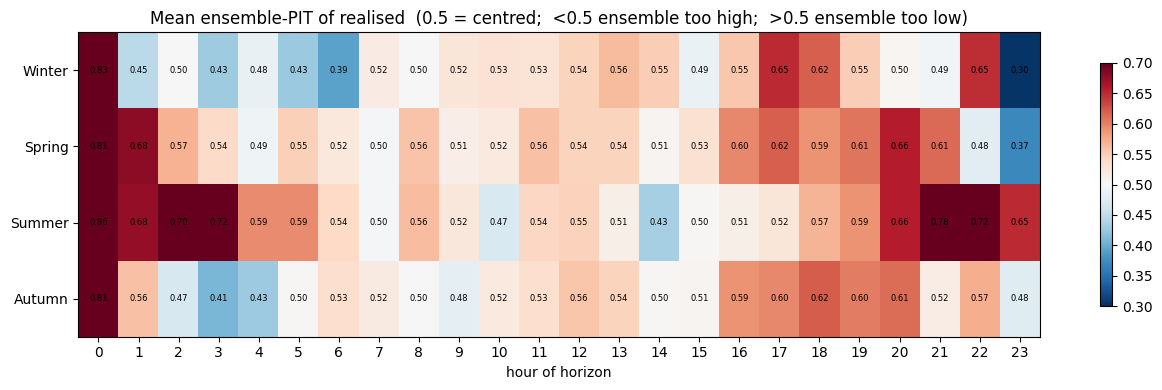

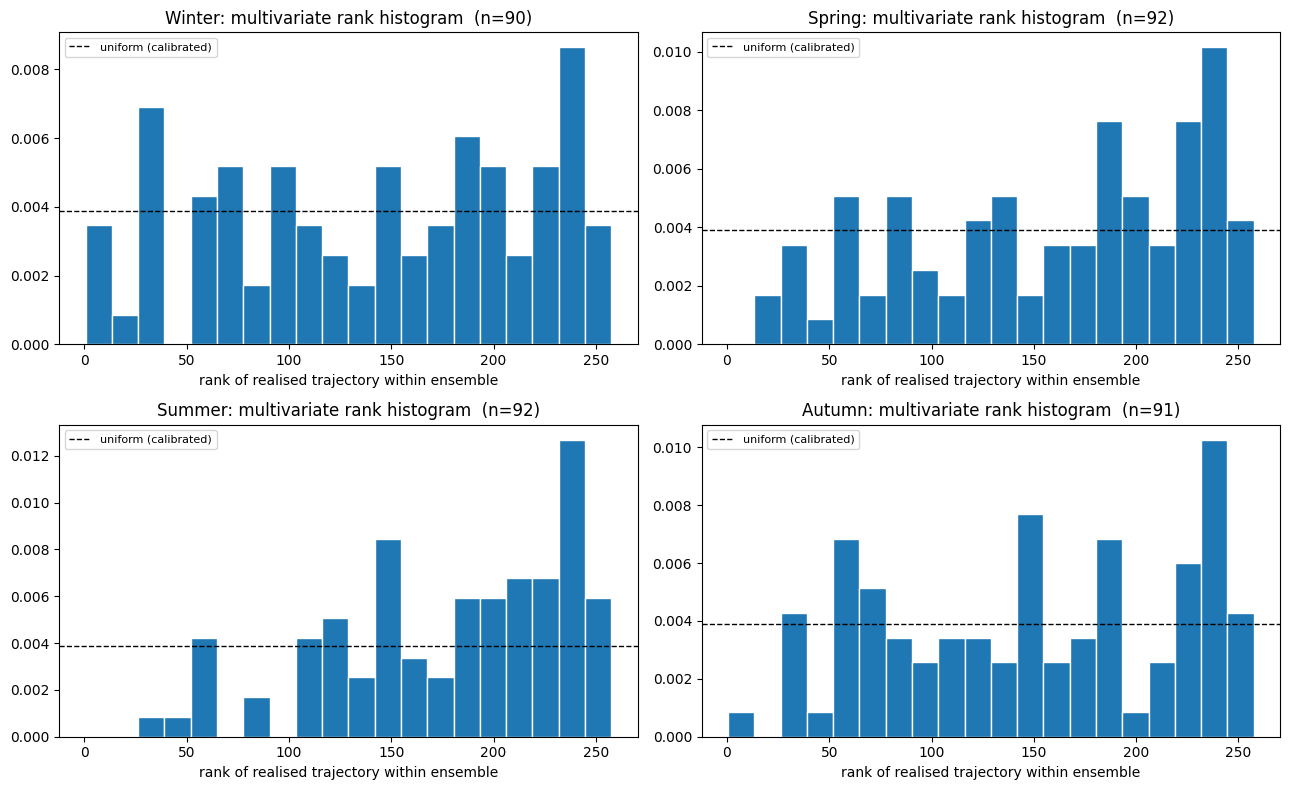

In [55]:
out = scenario_calibration_check(y, scenario_grid, year=2018)   # scenarios (N,S,24)